In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import argparse
from pathlib import Path
import csv


In [10]:
image_path = Path('.').parent / '../maps/cdc_2024/cdc_2024_edited.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")


Processing ../maps/cdc_2024/cdc_2024_edited.pgm...


In [9]:
# Load the image
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Could not load image from {image_path}")



In [ ]:
print(f"Loaded image with shape: {img.shape}")

# Threshold the image to create a binary image
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Invert if the track is white (assuming track is darker than background)
if np.mean(binary) > 127: # type: ignore
    binary = 255 - binary

Loaded image with shape: (2048, 2048)


In [14]:
# Find contours - for boundary extraction
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

1

In [15]:
contours

(array([[[1055,  895]],
 
        [[1054,  896]],
 
        [[1049,  896]],
 
        [[1048,  897]],
 
        [[1046,  897]],
 
        [[1045,  898]],
 
        [[1042,  898]],
 
        [[1041,  899]],
 
        [[1039,  899]],
 
        [[1038,  900]],
 
        [[1035,  900]],
 
        [[1034,  901]],
 
        [[1031,  901]],
 
        [[1030,  902]],
 
        [[1027,  902]],
 
        [[1026,  903]],
 
        [[1024,  903]],
 
        [[1023,  904]],
 
        [[1019,  904]],
 
        [[1018,  905]],
 
        [[1016,  905]],
 
        [[1015,  906]],
 
        [[1013,  906]],
 
        [[1012,  907]],
 
        [[1009,  907]],
 
        [[1008,  908]],
 
        [[1007,  908]],
 
        [[1004,  911]],
 
        [[1004,  913]],
 
        [[1003,  914]],
 
        [[1003,  916]],
 
        [[1002,  917]],
 
        [[1002,  918]],
 
        [[1001,  919]],
 
        [[1001,  921]],
 
        [[1000,  922]],
 
        [[1000,  924]],
 
        [[ 999,  925]],
 
        [[ 9

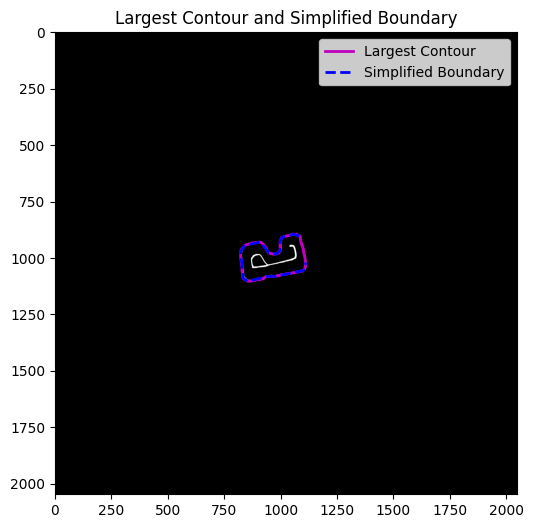

In [17]:

# Find the largest contour (assuming it's the track)
largest_contour = max(contours, key=cv2.contourArea)

# Simplify the contour to reduce number of points (Douglas-Peucker algorithm)
epsilon = 0.005 * cv2.arcLength(largest_contour, True)
boundary_points = cv2.approxPolyDP(largest_contour, epsilon, True)

# Extract coordinates for plotting
largest_contour_coords = [(point[0][0], point[0][1]) for point in largest_contour]
boundary_coords = [(point[0][0], point[0][1]) for point in boundary_points]

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
largest_x = [p[0] for p in largest_contour_coords]
largest_y = [p[1] for p in largest_contour_coords]
plt.plot(largest_x, largest_y, 'm-', linewidth=2, label='Largest Contour')
# Plot simplified boundary
boundary_x = [p[0] for p in boundary_coords]
boundary_y = [p[1] for p in boundary_coords]
plt.plot(boundary_x, boundary_y, 'b--', linewidth=2, label='Simplified Boundary')
plt.title('Largest Contour and Simplified Boundary')
plt.legend()
plt.show()


Smallest contour too small, might be noise.
No contours detected after erosion.


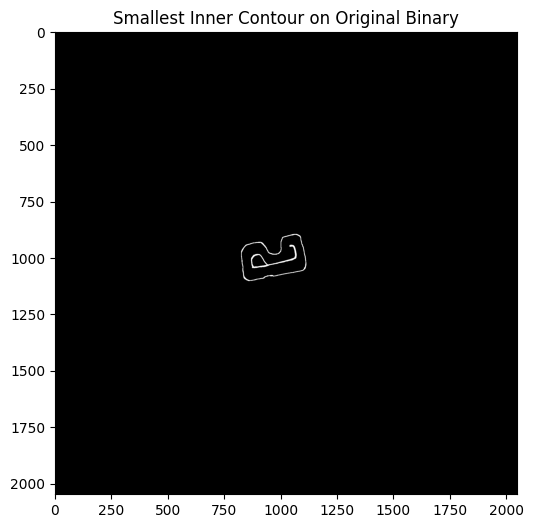

In [27]:

# Erode to create an artificial inner boundary
kernel = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=3)  # Adjust iterations as needed

# Extract all contours with hierarchy using RETR_CCOMP
contours, hierarchy = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Find the contour with the smallest area
inner_contour = None
if contours:
    inner_contour = min(contours, key=cv2.contourArea)
    # Optionally filter out tiny noise contours
    if cv2.contourArea(inner_contour) < 50:  # Adjust threshold as needed
        print("Smallest contour too small, might be noise.")
        inner_contour = None

# Simplify and get coordinates
if inner_contour is not None:
    epsilon = 0.005 * cv2.arcLength(inner_contour, True)
    inner_boundary = cv2.approxPolyDP(inner_contour, epsilon, True)
    inner_coords = [(point[0][0], point[0][1]) for point in inner_boundary]
    print(f"Smallest contour points: {len(inner_coords)}")
    print(f"First few points: {inner_coords[:5]}")
else:
    inner_coords = []
    print("No contours detected after erosion.")

# Plot the smallest contour
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')
if inner_coords:
    inner_x = [p[0] for p in inner_coords]
    inner_y = [p[1] for p in inner_coords]
    plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')
    plt.legend()
else:
    plt.title('No Inner Contour Found')
plt.title('Smallest Inner Contour on Original Binary')
plt.show()


In [ ]:





# Skeletonize to get centerline
# Distance transform + adaptive thresholding
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX)

# Improve skeleton by using an adaptive threshold based on max distance
max_dist = np.max(dist_transform[binary > 0])  # Max distance within track
factor = 0.5 ## Factor
thresh_value = max_dist * factor  # Threshold at half the max distance (adjustable)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin the skeleton with a single erosion step to refine it
kernel = np.ones((3, 3), np.uint8)
skeleton = cv2.erode(skeleton, kernel, iterations=1)

# Find centerline points
centerline_points = np.where(skeleton > 0)
centerline_coords = [(x, y) for y, x in zip(centerline_points[0], centerline_points[1])]

# Sort centerline points to follow the track
if len(centerline_coords) > 1:
    sorted_centerline = [centerline_coords[0]]
    remaining = centerline_coords[1:]
    
    while remaining:
        last_point = sorted_centerline[-1]
        distances = [np.sqrt((p[0] - last_point[0])**2 + (p[1] - last_point[1])**2) for p in remaining]
        closest_idx = np.argmin(distances)
        sorted_centerline.append(remaining[closest_idx])
        remaining.pop(closest_idx)
        
        # Break if remaining points are too far (gaps in track)
        if distances[closest_idx] > 20 and len(sorted_centerline) > len(centerline_coords) // 2:
            break
            
    centerline_coords = sorted_centerline

# Save to CSV if output path is provided
if output_path:
    with open(output_path / 'centerline.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(centerline_coords)
        
    with open(output_path / 'boundary.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(boundary_coords)

    plt.imsave(output_path / 'distance_transform.png', dist_norm, cmap='hot')
    plt.imsave(output_path / 'centerline.png', cv2.cvtColor(skeleton, cv2.COLOR_GRAY2RGB))
    plt.imsave(output_path / 'binary.png', binary, cmap='gray')
    plt.imsave(output_path / 'track.png', cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
    plt.imsave(output_path / 'track_with_coords.png', cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))    

# Visualize results
if visualize:
    plt.figure(figsize=(12, 10))
    
    # # Original image
    # plt.subplot(2, 2, 1)
    # plt.imshow(img, cmap='gray')
    # plt.title('Original Track Image')
    
    # # Binary image
    # plt.subplot(2, 2, 2)
    # plt.imshow(binary, cmap='gray')
    # plt.title('Binary Track Image')
    
    # # Distance transform
    # plt.subplot(2, 2, 3)
    # plt.imshow(dist_norm, cmap='hot')
    # plt.title('Distance Transform')
    
    # Result with coordinates
    # plt.subplot(2, 2, 4)
    plt.imshow(img, cmap='gray')
    centerline_x = [p[0] for p in centerline_coords]
    centerline_y = [p[1] for p in centerline_coords]
    plt.plot(centerline_x, centerline_y, 'g-', linewidth=2, label='Centerline')
    boundary_x = [p[0] for p in boundary_coords]
    boundary_y = [p[1] for p in boundary_coords]
    plt.plot(boundary_x, boundary_y, 'b-', linewidth=2, label='Boundary')
    plt.title('Extracted Track Coordinates')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    if output_path:
        plt.savefig(output_path / 'track_with_coords.png')

In [ ]:

# Load image to get dimensions
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

# Convert to ROS coordinates
ros_centerline = convert_to_ros_coordinates(centerline, img.shape[0], args.resolution)
ros_boundary = convert_to_ros_coordinates(boundary, img.shape[0], args.resolution)

# Save ROS coordinates
with open(output_path / 'ros_centerline.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['x', 'y'])
    writer.writerows(ros_centerline)
    
with open(output_path / 'ros_boundary.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['x', 'y'])
    writer.writerows(ros_boundary)

# Create ROS map YAML file if input is PGM
if image_path.suffix.lower() == '.pgm':
    create_ros_map_yaml(image_path, output_path, args.resolution)

print(f"Extracted {len(centerline)} centerline points and {len(boundary)} boundary points")
print(f"Results saved to {output_path}")